=== Overlap scan completed ===
alpha range: 0.00 -> 1.20
overlap range: 0.9578 -> 1.0000

Most interesting case (heuristic):
alpha = 0.600
overlap = 0.9804
mean chi2 A = 568.58
mean chi2 B = 487.10
mean delta chi2 = 81.48


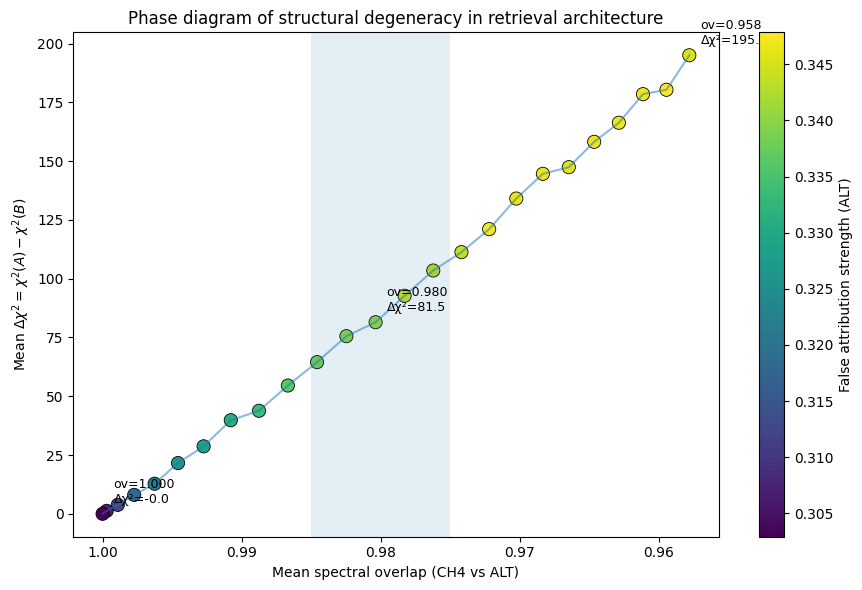

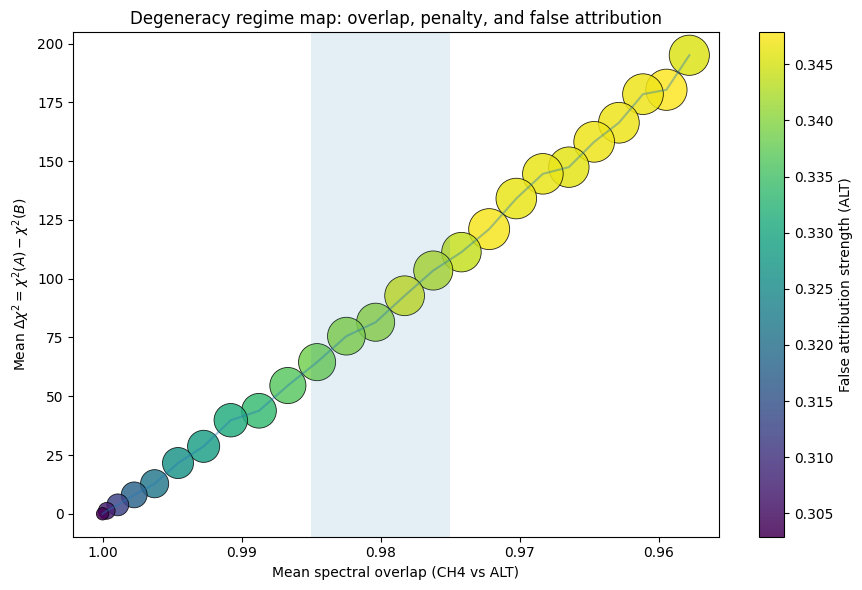

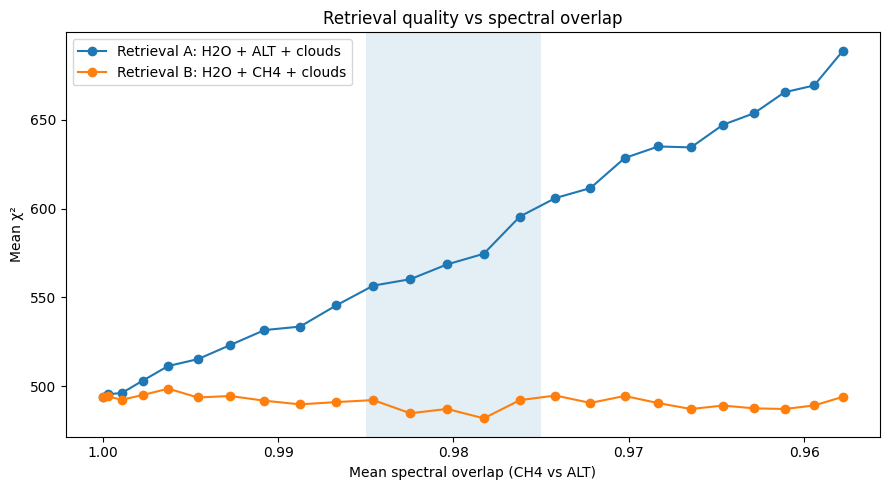

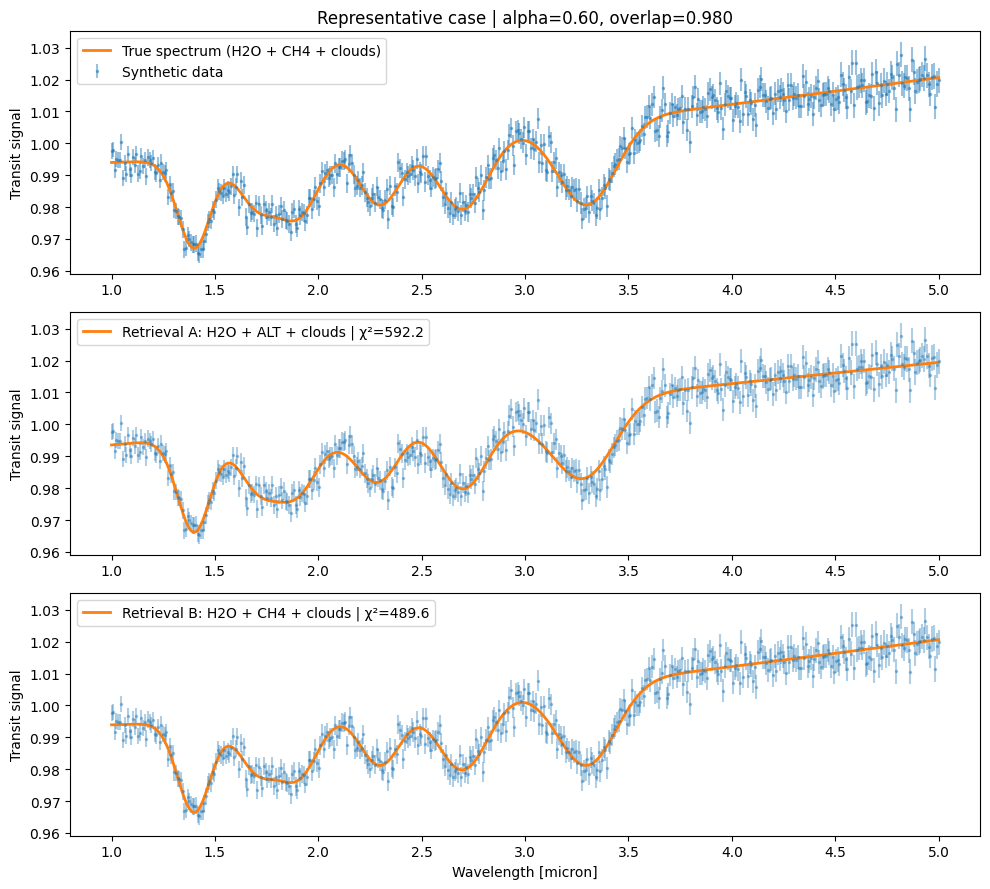


=== Phase diagram summary ===
Overlap range: 0.9578 -> 1.0000
Delta-chi2 range: -0.00 -> 195.04
ALT strength range: 0.3029 -> 0.3478

Representative moderate-strong degeneracy case:
Overlap = 0.9804
Mean Delta chi2 = 81.48
Mean ALT strength = 0.3407

Saved outputs in: /content/retrieval_overlap_scan_outputs


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================

SEED = 41
N_LAM = 500
LAM_MIN, LAM_MAX = 1.0, 5.0
N_RUNS = 100
ALPHAS = np.linspace(0.0, 1.2, 25)

# regime band to highlight in phase diagrams
REGIME_MIN = 0.975
REGIME_MAX = 0.985

# output folder
OUTDIR = Path("retrieval_overlap_scan_outputs")
OUTDIR.mkdir(exist_ok=True)

np.random.seed(SEED)

# ============================================================
# HELPERS
# ============================================================

def gauss(x: np.ndarray, mu: float, sig: float) -> np.ndarray:
    return np.exp(-0.5 * ((x - mu) / sig) ** 2)

def normalize_cols(M: np.ndarray) -> np.ndarray:
    M = M.copy()
    for j in range(M.shape[1]):
        n = np.linalg.norm(M[:, j])
        if n > 0:
            M[:, j] /= n
    return M

def block_strength(beta: np.ndarray, start: int, end: int) -> float:
    return float(np.sum(np.abs(beta[start:end])))

def mean_block_overlap(A: np.ndarray, B: np.ndarray) -> float:
    vals = []
    for j in range(A.shape[1]):
        a = A[:, j]
        b = B[:, j]
        vals.append(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))
    return float(np.mean(vals))

def wls_fit(X: np.ndarray, y: np.ndarray, w: np.ndarray, sigma: np.ndarray):
    XtW = X.T * w
    beta = np.linalg.solve(XtW @ X, XtW @ y)
    yhat = X @ beta
    resid = y - yhat
    chi2 = float(np.sum((resid / sigma) ** 2))
    return beta, yhat, resid, chi2

# ============================================================
# SYNTHETIC TRUTH
# ============================================================

lam = np.linspace(LAM_MIN, LAM_MAX, N_LAM)

continuum = 1.0 + 0.008 * (lam - 3.0)

B_h2o_true = np.column_stack([
    gauss(lam, 1.40, 0.08),
    gauss(lam, 1.90, 0.10),
    gauss(lam, 2.70, 0.12),
])

B_ch4_true = np.column_stack([
    gauss(lam, 1.70, 0.09),
    gauss(lam, 2.30, 0.10),
    gauss(lam, 3.30, 0.14),
])

amp_h2o = np.array([0.028, 0.020, 0.023])
amp_ch4 = np.array([0.015, 0.019, 0.026])

h2o_true = B_h2o_true @ amp_h2o
ch4_true = B_ch4_true @ amp_ch4

# simple cloud masking term
cloud_term = 0.010 * np.exp(-0.7 * (lam - 1.0)) + 0.004 * (lam - 1.0) / 4.0

true_signal = continuum - h2o_true - ch4_true + cloud_term

sigma = 0.0025 + 0.0015 * (lam - lam.min()) / (lam.max() - lam.min())
w = 1.0 / sigma**2

# retrieval bases
B_h2o = B_h2o_true.copy()
B_ch4 = B_ch4_true.copy()

B_cloud = np.column_stack([
    np.exp(-0.7 * (lam - 1.0)),
    (lam - 1.0) / 4.0
])

# distortion template used to build alternative molecular basis
B_dist = np.column_stack([
    gauss(lam, 1.78, 0.13),
    gauss(lam, 2.22, 0.14),
    gauss(lam, 3.18, 0.20),
])

B_ch4_norm = normalize_cols(B_ch4)
B_dist_norm = normalize_cols(B_dist)

# ============================================================
# OVERLAP SCAN
# ============================================================

rows = []

best_example = None
best_score = None

for alpha in ALPHAS:
    # ALT basis: CH4 plus controlled distortion
    B_alt = B_ch4_norm + alpha * B_dist_norm
    B_alt = normalize_cols(B_alt)

    overlap = mean_block_overlap(B_ch4_norm, B_alt)

    chi2_A_runs = []
    chi2_B_runs = []
    alt_runs = []
    ch4_runs = []
    cloud_A_runs = []
    cloud_B_runs = []

    for _ in range(N_RUNS):
        y_obs = true_signal + np.random.normal(0, sigma)

        # Retrieval A: H2O + ALT + clouds
        X_A = np.column_stack([
            np.ones_like(lam),
            lam - 3.0,
            B_h2o,
            B_alt,
            B_cloud
        ])

        # Retrieval B: H2O + CH4 + clouds
        X_B = np.column_stack([
            np.ones_like(lam),
            lam - 3.0,
            B_h2o,
            B_ch4,
            B_cloud
        ])

        beta_A, yhat_A, resid_A, chi2_A = wls_fit(X_A, y_obs, w, sigma)
        beta_B, yhat_B, resid_B, chi2_B = wls_fit(X_B, y_obs, w, sigma)

        chi2_A_runs.append(chi2_A)
        chi2_B_runs.append(chi2_B)
        alt_runs.append(block_strength(beta_A, 5, 8))
        ch4_runs.append(block_strength(beta_B, 5, 8))
        cloud_A_runs.append(block_strength(beta_A, 8, 10))
        cloud_B_runs.append(block_strength(beta_B, 8, 10))

    chi2_A_mean = float(np.mean(chi2_A_runs))
    chi2_B_mean = float(np.mean(chi2_B_runs))
    dchi2_mean = chi2_A_mean - chi2_B_mean

    row = {
        "alpha": float(alpha),
        "overlap": overlap,
        "chi2_A_mean": chi2_A_mean,
        "chi2_B_mean": chi2_B_mean,
        "delta_chi2_mean": dchi2_mean,
        "delta_chi2_std": float(np.std(np.array(chi2_A_runs) - np.array(chi2_B_runs))),
        "alt_strength_mean": float(np.mean(alt_runs)),
        "alt_strength_std": float(np.std(alt_runs)),
        "ch4_strength_mean": float(np.mean(ch4_runs)),
        "cloud_A_mean": float(np.mean(cloud_A_runs)),
        "cloud_B_mean": float(np.mean(cloud_B_runs)),
    }
    rows.append(row)

    # heuristic: high overlap but still nonzero/moderate penalty
    score = overlap - 0.001 * abs(dchi2_mean - 80)
    if best_score is None or score > best_score:
        best_score = score
        best_example = {
            "alpha": alpha,
            "overlap": overlap,
            "chi2_A_mean": chi2_A_mean,
            "chi2_B_mean": chi2_B_mean,
            "dchi2_mean": dchi2_mean,
            "B_alt": B_alt
        }

results = pd.DataFrame(rows).sort_values("overlap").reset_index(drop=True)
results.to_csv(OUTDIR / "overlap_scan_results.csv", index=False)

print("=== Overlap scan completed ===")
print(f"alpha range: {results['alpha'].min():.2f} -> {results['alpha'].max():.2f}")
print(f"overlap range: {results['overlap'].min():.4f} -> {results['overlap'].max():.4f}")
print("\nMost interesting case (heuristic):")
print(f"alpha = {best_example['alpha']:.3f}")
print(f"overlap = {best_example['overlap']:.4f}")
print(f"mean chi2 A = {best_example['chi2_A_mean']:.2f}")
print(f"mean chi2 B = {best_example['chi2_B_mean']:.2f}")
print(f"mean delta chi2 = {best_example['dchi2_mean']:.2f}")

# ============================================================
# PHASE DIAGRAM 1
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

sc = ax.scatter(
    results["overlap"],
    results["delta_chi2_mean"],
    c=results["alt_strength_mean"],
    s=90,
    edgecolors="black",
    linewidths=0.6
)
ax.plot(results["overlap"], results["delta_chi2_mean"], alpha=0.5)

# highlight quasi-degenerate regime
ax.axvspan(REGIME_MIN, REGIME_MAX, alpha=0.12)
ax.invert_xaxis()

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("False attribution strength (ALT)")

ax.set_xlabel("Mean spectral overlap (CH4 vs ALT)")
ax.set_ylabel(r"Mean $\Delta \chi^2 = \chi^2(A) - \chi^2(B)$")
ax.set_title("Phase diagram of structural degeneracy in retrieval architecture")

# annotate representative points
rep_idx = [
    0,
    int(np.argmin(np.abs(results["overlap"] - 0.980))),
    len(results) - 1
]
for i in rep_idx:
    x = results.loc[i, "overlap"]
    y = results.loc[i, "delta_chi2_mean"]
    ax.annotate(
        f"ov={x:.3f}\nΔχ²={y:.1f}",
        (x, y),
        textcoords="offset points",
        xytext=(8, 8),
        fontsize=9
    )

plt.tight_layout()
plt.savefig(OUTDIR / "phase_diagram_structural_degeneracy.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# PHASE DIAGRAM 2 (bubble map)
# ============================================================

sizes = (
    800
    * (results["alt_strength_mean"] - results["alt_strength_mean"].min())
    / (results["alt_strength_mean"].max() - results["alt_strength_mean"].min() + 1e-12)
    + 80
)

fig, ax = plt.subplots(figsize=(9, 6))

sc = ax.scatter(
    results["overlap"],
    results["delta_chi2_mean"],
    c=results["alt_strength_mean"],
    s=sizes,
    edgecolors="black",
    linewidths=0.6,
    alpha=0.85
)
ax.plot(results["overlap"], results["delta_chi2_mean"], alpha=0.4)
ax.axvspan(REGIME_MIN, REGIME_MAX, alpha=0.12)
ax.invert_xaxis()

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("False attribution strength (ALT)")

ax.set_xlabel("Mean spectral overlap (CH4 vs ALT)")
ax.set_ylabel(r"Mean $\Delta \chi^2 = \chi^2(A) - \chi^2(B)$")
ax.set_title("Degeneracy regime map: overlap, penalty, and false attribution")

plt.tight_layout()
plt.savefig(OUTDIR / "degeneracy_regime_map.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# RETRIEVAL QUALITY CURVE
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(results["overlap"], results["chi2_A_mean"], marker="o", label="Retrieval A: H2O + ALT + clouds")
ax.plot(results["overlap"], results["chi2_B_mean"], marker="o", label="Retrieval B: H2O + CH4 + clouds")
ax.axvspan(REGIME_MIN, REGIME_MAX, alpha=0.12)
ax.invert_xaxis()
ax.set_xlabel("Mean spectral overlap (CH4 vs ALT)")
ax.set_ylabel("Mean χ²")
ax.set_title("Retrieval quality vs spectral overlap")
ax.legend()
plt.tight_layout()
plt.savefig(OUTDIR / "retrieval_quality_vs_overlap.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# REPRESENTATIVE CASE
# ============================================================

alpha = best_example["alpha"]
B_alt = best_example["B_alt"]

y_obs = true_signal + np.random.normal(0, sigma)

X_A = np.column_stack([
    np.ones_like(lam),
    lam - 3.0,
    B_h2o,
    B_alt,
    B_cloud
])

X_B = np.column_stack([
    np.ones_like(lam),
    lam - 3.0,
    B_h2o,
    B_ch4,
    B_cloud
])

beta_A, yhat_A, resid_A, chi2_A = wls_fit(X_A, y_obs, w, sigma)
beta_B, yhat_B, resid_B, chi2_B = wls_fit(X_B, y_obs, w, sigma)

fig = plt.figure(figsize=(10, 9))

ax1 = plt.subplot(3, 1, 1)
ax1.errorbar(lam, y_obs, yerr=sigma, fmt='.', ms=3, alpha=0.45, label='Synthetic data')
ax1.plot(lam, true_signal, lw=2, label='True spectrum (H2O + CH4 + clouds)')
ax1.set_ylabel("Transit signal")
ax1.set_title(f"Representative case | alpha={alpha:.2f}, overlap={best_example['overlap']:.3f}")
ax1.legend()

ax2 = plt.subplot(3, 1, 2, sharex=ax1)
ax2.errorbar(lam, y_obs, yerr=sigma, fmt='.', ms=3, alpha=0.35)
ax2.plot(lam, yhat_A, lw=2, label=f"Retrieval A: H2O + ALT + clouds | χ²={chi2_A:.1f}")
ax2.set_ylabel("Transit signal")
ax2.legend()

ax3 = plt.subplot(3, 1, 3, sharex=ax1)
ax3.errorbar(lam, y_obs, yerr=sigma, fmt='.', ms=3, alpha=0.35)
ax3.plot(lam, yhat_B, lw=2, label=f"Retrieval B: H2O + CH4 + clouds | χ²={chi2_B:.1f}")
ax3.set_ylabel("Transit signal")
ax3.set_xlabel("Wavelength [micron]")
ax3.legend()

plt.tight_layout()
plt.savefig(OUTDIR / "representative_case.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# TEXT SUMMARY
# ============================================================

rep = results.iloc[(results["delta_chi2_mean"] - 80).abs().argmin()]

print("\n=== Phase diagram summary ===")
print(f"Overlap range: {results['overlap'].min():.4f} -> {results['overlap'].max():.4f}")
print(f"Delta-chi2 range: {results['delta_chi2_mean'].min():.2f} -> {results['delta_chi2_mean'].max():.2f}")
print(f"ALT strength range: {results['alt_strength_mean'].min():.4f} -> {results['alt_strength_mean'].max():.4f}")
print("\nRepresentative moderate-strong degeneracy case:")
print(f"Overlap = {rep['overlap']:.4f}")
print(f"Mean Delta chi2 = {rep['delta_chi2_mean']:.2f}")
print(f"Mean ALT strength = {rep['alt_strength_mean']:.4f}")
print(f"\nSaved outputs in: {OUTDIR.resolve()}")